In [1]:
import tensorflow as tf
tf.__version__
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)
tf.config.set_visible_devices(gpus[1], "GPU")


2024-12-07 10:44:56.226624: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1733539496.249982   26523 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1733539496.257178   26523 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-12-07 10:44:56.283082: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [10]:
import numpy as np

np.stack([np.random.randn(5).reshape(5).reshape(5,1).reshape(5), 
np.random.randn(5).reshape(5).reshape(5,1).reshape(5)])


array([[ 1.47948802,  0.99822727, -0.95638518, -1.47784071,  0.38362904],
       [-1.4210795 , -0.34665677, -0.78462516, -0.7201532 , -0.62988032]])

In [16]:
data = tf.random.normal((3,3))
print(data)
idx = tf.random.shuffle(tf.range(3))
print(idx)
print(tf.gather(data, idx))
print(tf.transpose(data))

tf.Tensor(
[[ 0.5383679   0.2604863  -0.8485892 ]
 [ 0.7607709  -0.99327785 -0.3331311 ]
 [ 0.0624269  -1.2915107  -1.596325  ]], shape=(3, 3), dtype=float32)
tf.Tensor([1 0 2], shape=(3,), dtype=int32)
tf.Tensor(
[[ 0.7607709  -0.99327785 -0.3331311 ]
 [ 0.5383679   0.2604863  -0.8485892 ]
 [ 0.0624269  -1.2915107  -1.596325  ]], shape=(3, 3), dtype=float32)
tf.Tensor(
[[ 0.5383679   0.7607709   0.0624269 ]
 [ 0.2604863  -0.99327785 -1.2915107 ]
 [-0.8485892  -0.3331311  -1.596325  ]], shape=(3, 3), dtype=float32)


In [8]:
tf.gather(tf.range(3), tf.random.shuffle(tf.range(3)))

<tf.Tensor: shape=(3,), dtype=int32, numpy=array([2, 1, 0], dtype=int32)>

In [85]:
tf.reduce_mean(np.random.normal(size=5))

<tf.Tensor: shape=(), dtype=float64, numpy=-0.26302270444041137>

(3, 4)


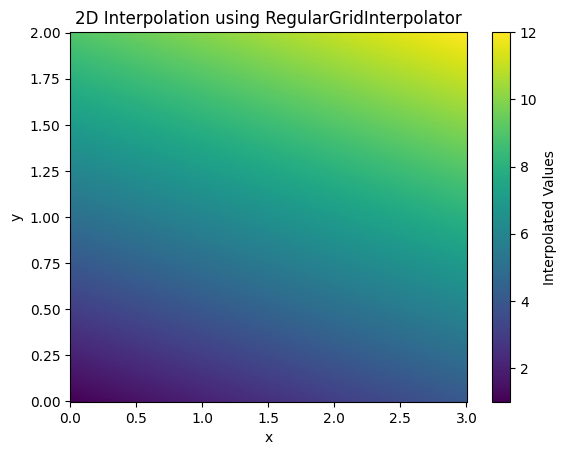

In [75]:
import numpy as np
from scipy.interpolate import RegularGridInterpolator
import matplotlib.pyplot as plt

# Define the grid points
x = np.array([0, 1, 2, 3])
y = np.array([0, 1, 2])
z = np.array([
    [1, 2, 3, 4],  # z-values at y=0
    [5, 6, 7, 8],  # z-values at y=1
    [9, 10, 11, 12]  # z-values at y=2
])

print(z.shape)

# Create the interpolation function
f = RegularGridInterpolator((y, x), z)

# Interpolate at new points
x_new = np.linspace(0, 3, 500)
y_new = np.linspace(0, 2, 300)
x_grid, y_grid = np.meshgrid(x_new, y_new)
z_new = f((y_grid, x_grid))  # Note: order is (y, x)

# Plot the result
plt.pcolormesh(x_new, y_new, z_new, shading='auto', cmap='viridis')
plt.colorbar(label='Interpolated Values')
plt.xlabel('x')
plt.ylabel('y')
plt.title('2D Interpolation using RegularGridInterpolator')
plt.show()

In [80]:
from scipy.interpolate import RegularGridInterpolator
import numpy as np
def f(x, y, z):
    return 2 * x**3 + 3 * y**2 - z
x = np.linspace(1, 4, 11)
y = np.linspace(4, 7, 22)
z = np.linspace(7, 9, 33)
xg, yg ,zg = np.meshgrid(x, y, z, sparse=True)
data = f(xg, yg, zg)

In [83]:
zg.shape

(1, 1, 33)

In [81]:
yg.shape

(22, 1, 1)

In [1]:
100/6

16.666666666666668

In [62]:
import numpy as np
import tensorflow as tf
from src import functions
H_function = functions.functions("1D_Gauss_mix")

y = tf.convert_to_tensor(np.random.normal(size=(50,1)), dtype=tf.float32)
x = tf.convert_to_tensor(np.random.normal(size=(100,1)), dtype=tf.float32)
# x = tf.constant([1], dtype=tf.float32)

with tf.GradientTape() as tape:
    tape.watch(x)
    # z = x + 1 
    # z = tf.matmul(tf.transpose(x), x)
    # z = tf.linalg.inv(tf.matmul(tf.transpose(x), x))
    xp = tf.reshape(x, shape=(-1,2))
    z = tf.matmul(tf.linalg.inv(tf.matmul(tf.transpose(xp), xp)), tf.matmul(tf.transpose(xp),y))
    z = tf.reduce_sum(z)
res = tape.gradient(z,x)
res


<tf.Tensor: shape=(100, 1), dtype=float32, numpy=
array([[ 0.0230942 ],
       [ 0.01634023],
       [ 0.0036922 ],
       [ 0.00313709],
       [ 0.00246583],
       [ 0.00179281],
       [ 0.0183342 ],
       [ 0.01218596],
       [-0.00380488],
       [-0.00206386],
       [-0.02743445],
       [-0.01917088],
       [-0.00145979],
       [-0.00164435],
       [-0.0243901 ],
       [-0.01705246],
       [-0.03633938],
       [-0.02544658],
       [ 0.05865986],
       [ 0.04132116],
       [-0.01817726],
       [-0.01313167],
       [ 0.00261961],
       [ 0.00233867],
       [ 0.01316068],
       [ 0.00880885],
       [-0.0100943 ],
       [-0.00670776],
       [-0.03673946],
       [-0.02611243],
       [-0.04559987],
       [-0.03148697],
       [-0.01459775],
       [-0.0098938 ],
       [ 0.01910479],
       [ 0.0137392 ],
       [ 0.00770563],
       [ 0.00499365],
       [-0.04214977],
       [-0.02988156],
       [-0.00219292],
       [-0.00165278],
       [ 0.0199782 ],
    

In [49]:
res == None

False

In [1]:
import tensorflow as tf

# Define a tensor
tensor = tf.constant([[1], [2], [3]])  # Shape: [3, 1]

# Broadcast to target shape [3, 4]
broadcasted_tensor = tf.broadcast_to(tensor, [3, 4])

print("Broadcasted Tensor:")
print(broadcasted_tensor.numpy())

2025-01-28 20:38:06.186152: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1738067886.208385  909922 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1738067886.215390  909922 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-01-28 20:38:06.240951: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Broadcasted Tensor:
[[1 1 1 1]
 [2 2 2 2]
 [3 3 3 3]]


I0000 00:00:1738067890.257797  909922 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 14784 MB memory:  -> device: 0, name: Tesla V100-PCIE-16GB, pci bus id: 0000:3b:00.0, compute capability: 7.0
I0000 00:00:1738067890.258486  909922 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 14784 MB memory:  -> device: 1, name: Tesla V100-PCIE-16GB, pci bus id: 0000:af:00.0, compute capability: 7.0
I0000 00:00:1738067890.259312  909922 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 14784 MB memory:  -> device: 2, name: Tesla V100-PCIE-16GB, pci bus id: 0000:d8:00.0, compute capability: 7.0


In [2]:
import numpy as np
import tensorflow as tf
from src import gene_data
from src.configs import CONFIGS
from src import hnn


config = CONFIGS["LHNN_HMC_1DGaussianmixture"] # load the config which records all experiment parameters.
data = gene_data.get_dataset(**config)

ModuleNotFoundError: No module named 'utils'

In [42]:
z

<tf.Tensor: shape=(1,), dtype=float32, numpy=array([6.], dtype=float32)>

In [1]:
import tensorflow_probability as tfb

In [15]:
mnist = tf.keras.datasets.mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()


In [16]:
x_train, x_test = x_train / 255.0, x_test / 255.0

In [18]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(10)
])

In [26]:
predictions = tf.nn.softmax(model(x_train[:1]))

In [27]:
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

In [29]:
loss_fn(y_train[:1], predictions)

<tf.Tensor: shape=(), dtype=float32, numpy=2.2876944541931152>

In [31]:
model.compile(
    optimizer = "adam",
    loss = loss_fn,
    metrics = ["accuracy"]
)

In [33]:
model.fit(x_train, y_train, epochs=5)

Epoch 1/5


I0000 00:00:1731234444.466738 1814121 service.cc:148] XLA service 0x7ff16000a6d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1731234444.466797 1814121 service.cc:156]   StreamExecutor device (0): Tesla V100-PCIE-16GB, Compute Capability 7.0
I0000 00:00:1731234444.466818 1814121 service.cc:156]   StreamExecutor device (1): Tesla V100-PCIE-16GB, Compute Capability 7.0
I0000 00:00:1731234444.466837 1814121 service.cc:156]   StreamExecutor device (2): Tesla V100-PCIE-16GB, Compute Capability 7.0
2024-11-10 18:27:24.498943: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1731234444.560341 1814121 cuda_dnn.cc:529] Loaded cuDNN version 90300


  93/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5358 - loss: 1.4747

I0000 00:00:1731234445.335760 1814121 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8573 - loss: 0.4829
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9550 - loss: 0.1543
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9656 - loss: 0.1119
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9737 - loss: 0.0883
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9762 - loss: 0.0765


In [36]:
model.evaluate(x_test,y_test, verbose=2)

313/313 - 1s - 3ms/step - accuracy: 0.9764 - loss: 0.0713


[0.07127460092306137, 0.9764000177383423]

In [3]:
import tensorflow as tf

mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

x_train = x_train[...,tf.newaxis].astype("float32")
x_test = x_test[...,tf.newaxis].astype("float32")

trainds = tf.data.Dataset.from_tensor_slices((x_train, y_train)).shuffle(10000).batch(32)
testds = tf.data.Dataset.from_tensor_slices((x_test, y_test)).batch(32)


I0000 00:00:1733151435.084246 3747752 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 505 MB memory:  -> device: 0, name: Tesla V100-PCIE-16GB, pci bus id: 0000:3b:00.0, compute capability: 7.0
I0000 00:00:1733151435.084942 3747752 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 14478 MB memory:  -> device: 1, name: Tesla V100-PCIE-16GB, pci bus id: 0000:af:00.0, compute capability: 7.0
I0000 00:00:1733151435.085455 3747752 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 14478 MB memory:  -> device: 2, name: Tesla V100-PCIE-16GB, pci bus id: 0000:d8:00.0, compute capability: 7.0


In [7]:
for x, y in trainds:
    print(x)
    break

tf.Tensor(
[[[[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  ...

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]]


 [[[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  ...

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]]


 [[[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  ...

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0

In [88]:
from tensorflow.keras.layers import Dense, Flatten, Conv2D
from tensorflow.keras import Model

class Mymodel(Model):
    def __init__(self):
        super().__init__()
        self.conv2d = Conv2D(32, 3, activation = "relu")
        self.flatten = Flatten()
        self.d1 = Dense(128, activation="relu")
        self.d2 = Dense(10)

    def call(self, x):
        x = self.conv2d(x)
        x = self.flatten(x)
        x = self.d1(x)
        return self.d2(x)

In [89]:
model = Mymodel()

model

<Mymodel name=mymodel_7, built=False>

In [90]:
loss_obj = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

optimizer = tf.keras.optimizers.Adam()

In [91]:
train_loss = tf.keras.metrics.Mean(name="train_loss")
train_accuracy = tf.keras.metrics.SparseCategoricalAccuracy(name="train_accuracy")

test_loss = tf.keras.metrics.Mean(name="test_loss")
test_accuracy = tf.keras.metrics.SparseCategoricalAccuracy(name="test_accuracy")

In [92]:
@tf.function
def train_step(x,y):
    with tf.GradientTape() as tape:
        y_pred = model(x, training=True)
        loss = loss_obj(y,y_pred)
    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))

    train_loss(loss)
    train_accuracy(y,y_pred)

@tf.function
def test_step(x,y):
    y_pred = model(x, training=False)
    loss = loss_obj(y,y_pred)

    test_loss(loss)
    test_accuracy(y,y_pred)


In [93]:
EPOCHS = 5

for epoch in range(EPOCHS):
    train_loss.reset_state()
    train_accuracy.reset_state()
    test_loss.reset_state()
    test_accuracy.reset_state()

    for x, y in trainds:
        train_step(x,y)
    
    for x, y in testds:
        test_step(x,y)

    print(f"Finished the {epoch}th epoch:")
    print(f"TrainLoss: {train_loss.result():0.2f}")
    print(f"TrainAccuracy: {train_accuracy.result() * 100 :2f}")
    print(f"TestLoss: {test_loss.result():0.2f}")
    print(f"TestAccuracy: {test_accuracy.result() * 100 :2f}")


Finished the 0th epoch:
TrainLoss: 0.13
TrainAccuracy: 95.983330
TestLoss: 0.06
TestAccuracy: 97.959999
Finished the 1th epoch:
TrainLoss: 0.04
TrainAccuracy: 98.625000
TestLoss: 0.05
TestAccuracy: 98.169998
Finished the 2th epoch:
TrainLoss: 0.02
TrainAccuracy: 99.333336
TestLoss: 0.06
TestAccuracy: 98.269997


KeyboardInterrupt: 

In [66]:
x, y =list(trainds.as_numpy_iterator())[0]

In [69]:
i = model(x, training=True)

In [79]:
i = model(tf.random.normal([32,28,28,1]), training=True)

In [1]:
import numpy as np
import tensorflow as tf

2025-02-02 12:38:21.776640: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1738471101.797153 2009435 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1738471101.803537 2009435 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-02-02 12:38:21.826672: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
from src.functions import functions
from src import utils
from src import hnn

In [3]:
H = functions(dist_name="pmglmm")

I0000 00:00:1738471104.396266 2009435 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 497 MB memory:  -> device: 0, name: Tesla V100-PCIE-16GB, pci bus id: 0000:3b:00.0, compute capability: 7.0
I0000 00:00:1738471104.397351 2009435 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 14476 MB memory:  -> device: 1, name: Tesla V100-PCIE-16GB, pci bus id: 0000:af:00.0, compute capability: 7.0
I0000 00:00:1738471104.398296 2009435 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 14478 MB memory:  -> device: 2, name: Tesla V100-PCIE-16GB, pci bus id: 0000:d8:00.0, compute capability: 7.0


In [4]:
H_B = functions(dist_name="pmglmmB")

In [6]:
pmgrad_fn_auto = utils.getpmgrad_fn(H_B)

from src.configs import CONFIGS
config = CONFIGS["LHNN_pmglmm"]
config["num_hidden"] = 500
model = hnn.HNN(config["input_dim"], config["num_hidden"], config["num_layers"], config["output_dim"], acti=config["acti"], baseline=config["baseline"], field_type=config["field_type"])
model.load_weights("/home/ycui/Documents/TSRLproject_JPMorgan/models/LHNN_pmglmmB_sin.weights.h5")

def pmgrad_fn_lhnn(theta, u, rho, p):
    cur_state = tf.reshape(tf.convert_to_tensor(np.concat([theta, u, rho, p],axis=0), dtype=tf.float32), [1,-1])
    grad = tf.reshape(model.get_gradient(cur_state),[-1]).numpy()[len(theta)+len(u):]
    return grad[0:len(theta)], grad[len(theta):]


2025-02-02 12:39:15.064451: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:497] Allocator (GPU_0_bfc) ran out of memory trying to allocate 16B (rounded to 256)requested by op FloorMod
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
2025-02-02 12:39:15.064553: I external/local_xla/xla/tsl/framework/bfc_allocator.cc:1053] BFCAllocator dump for GPU_0_bfc
2025-02-02 12:39:15.064598: I external/local_xla/xla/tsl/framework/bfc_allocator.cc:1060] Bin (256): 	Total Chunks: 7, Chunks in use: 7. 1.8KiB allocated for chunks. 1.8KiB in use in bin. 64B client-requested in use in bin.
2025-02-02 12:39:15.064629: I external/local_xla/xla/tsl/framework/bfc_allocator.cc:1060] Bin (512): 	Total Chunks: 0, Chunks in use: 0. 0B allocated for chunks. 0B in use in bin. 0B client-requested in use in bin.
2025-02-02 12:39:15.064659: I external/l

ResourceExhaustedError: {{function_node __wrapped__FloorMod_device_/job:localhost/replica:0/task:0/device:GPU:0}} failed to allocate memory [Op:FloorMod] name: 

In [13]:
rho = np.random.normal(size=13)
p = np.random.normal(size=len(utils.get_latent_u(500*128)))

grad_auto = pmgrad_fn_auto(utils.get_marginal_initial(), utils.get_latent_u(500*128), rho, p)
grad_lhnn = pmgrad_fn_lhnn(utils.get_marginal_initial(), utils.get_latent_u(500*128), rho, p)


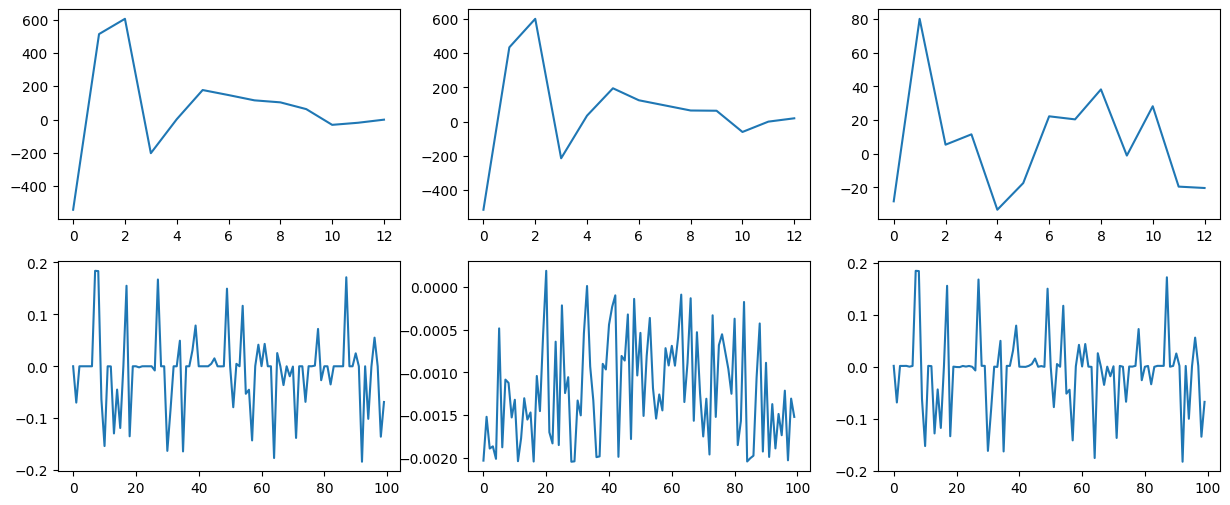

In [14]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 3, figsize=(15, 6)) 
for i in range(2):
    axes[i,0].plot(grad_auto[i][:100])
    axes[i,1].plot(grad_lhnn[i][:100])
    axes[i,2].plot(grad_auto[i][:100]-grad_lhnn[i][:100])

In [30]:
import numpy as np

rho = np.random.normal(size=13)
p = np.random.normal(size=len(utils.get_latent_u(500*128)))
states = utils.pmintegrator(utils.get_marginal_initial(), utils.get_latent_u(500*128), rho, p, pmgrad_fn_lhnn, 0.001, 100)

In [31]:
Hs = np.array([H(_state) for _state in states])

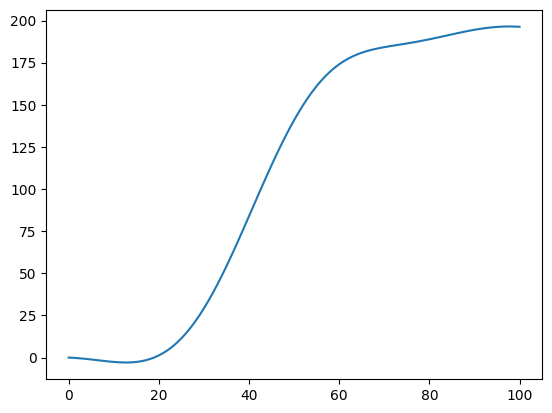

In [32]:
import matplotlib.pyplot as plt
plt.plot(Hs[:]-Hs[0])

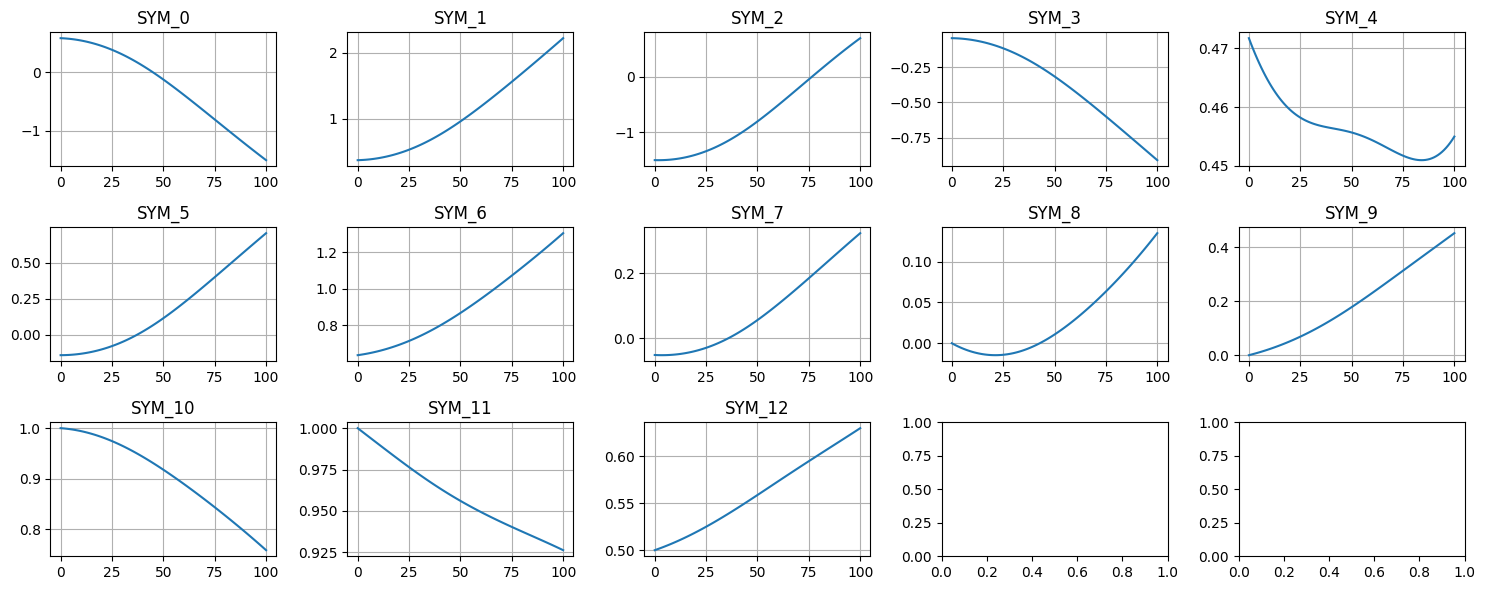

In [33]:
import numpy as np
import matplotlib.pyplot as plt
fig, axes = plt.subplots(3, 5, figsize=(15, 6))
axes = axes.flatten()
for i in range(13):
    axes[i].plot(states[:,i])
    axes[i].set_title(f"SYM_{i}")
    axes[i].grid(True)
plt.tight_layout()
plt.show()

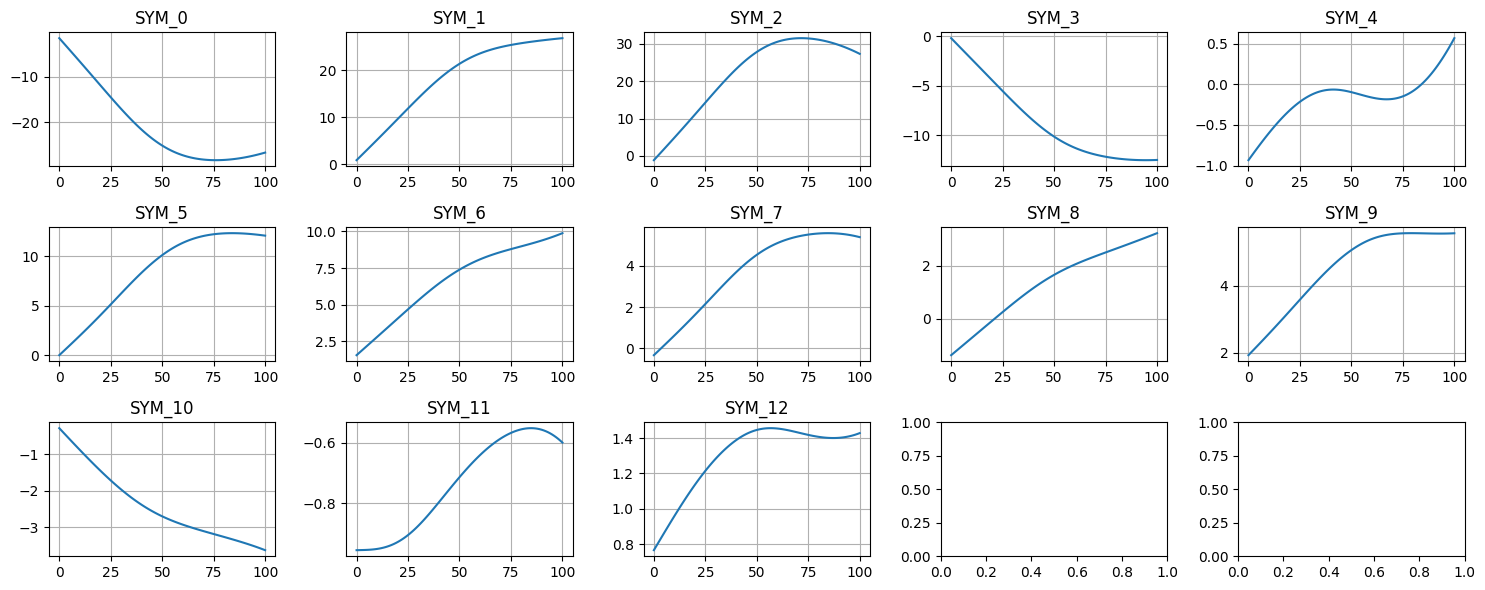

In [34]:
import numpy as np
import matplotlib.pyplot as plt
fig, axes = plt.subplots(3, 5, figsize=(15, 6)) 
axes = axes.flatten()
for i in range(13):
    axes[i].plot(states[:,len(states[0])//2 + i])
    axes[i].set_title(f"SYM_{i}")
    axes[i].grid(True)
plt.tight_layout()
plt.show()

In [79]:
data["timegrads"][0][len(data["states"][0])//2 + 40284]

np.float64(37.67514503176454)

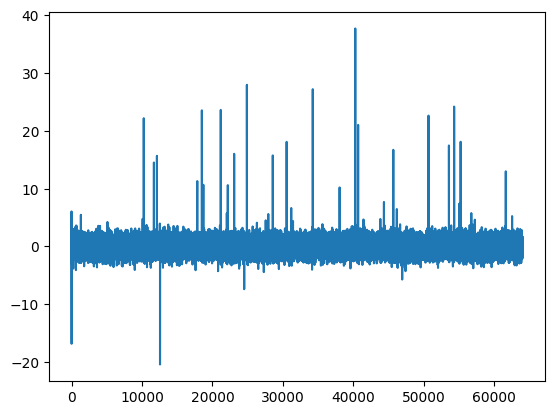

In [60]:
plt.plot(data["states"][2][:len(data["states"][0])//2])

In [4]:
import numpy as np

In [3]:
import pickle

with open("/home/ycui/Documents/TSRLproject_JPMorgan/samples/lhnn_hmc_pmglmm_100.pkl", "rb") as f:
    data = pickle.load(f)

In [4]:
data

{'samples': array([[[ 0.5838,  0.3805, -1.5062, ...,  1.    ,  1.    ,  0.5   ],
         [ 0.5838,  0.3805, -1.5062, ...,  1.    ,  1.    ,  0.5   ],
         [ 0.5838,  0.3805, -1.5062, ...,  1.    ,  1.    ,  0.5   ],
         ...,
         [ 0.5838,  0.3805, -1.5062, ...,  1.    ,  1.    ,  0.5   ],
         [ 0.5838,  0.3805, -1.5062, ...,  1.    ,  1.    ,  0.5   ],
         [ 0.5838,  0.3805, -1.5062, ...,  1.    ,  1.    ,  0.5   ]]]),
 'numgrad': None,
 'monitor': None,
 'accept': array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0.]])}

In [5]:
import numpy as np
np.mean(data["accept"])

np.float64(0.0)

In [6]:
data["samples"][0]

array([[ 0.5838,  0.3805, -1.5062, ...,  1.    ,  1.    ,  0.5   ],
       [ 0.5838,  0.3805, -1.5062, ...,  1.    ,  1.    ,  0.5   ],
       [ 0.5838,  0.3805, -1.5062, ...,  1.    ,  1.    ,  0.5   ],
       ...,
       [ 0.5838,  0.3805, -1.5062, ...,  1.    ,  1.    ,  0.5   ],
       [ 0.5838,  0.3805, -1.5062, ...,  1.    ,  1.    ,  0.5   ],
       [ 0.5838,  0.3805, -1.5062, ...,  1.    ,  1.    ,  0.5   ]])

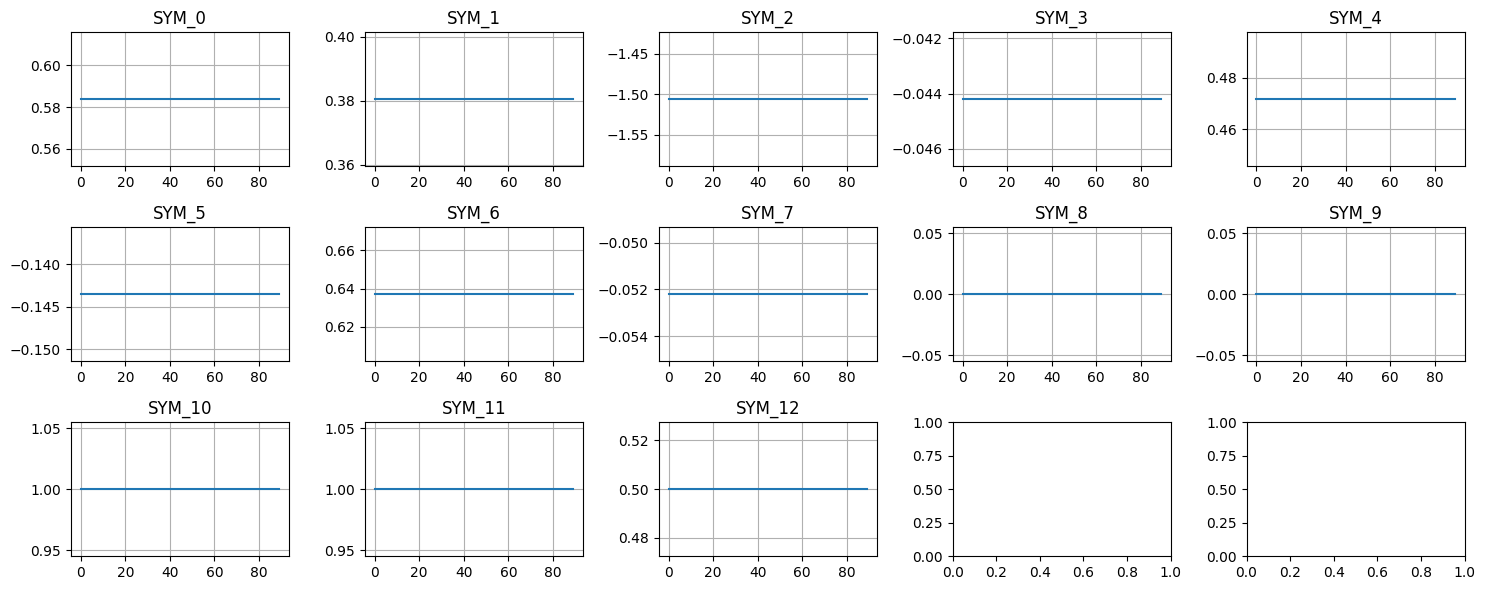

In [7]:
def plotsth(states,):
    import numpy as np
    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(3, 5, figsize=(15, 6))
    axes = axes.flatten()
    for i in range(13):
        axes[i].plot(states[10:,i])
        axes[i].set_title(f"SYM_{i}")
        axes[i].grid(True)
    plt.tight_layout()
    plt.show()

# plotsth(data["states"])
# plotsth(data["states"][:,len(data["states"][0])//2:])
plotsth(data["samples"][0])

In [14]:
[-1.1671, 2.4665, -0.1918, -1.0080, 0.6212, 0.6524, 1.5410, 0.2653, np.log(10), np.log(3), np.log(4)] 

[-1.1671,
 2.4665,
 -0.1918,
 -1.008,
 0.6212,
 0.6524,
 1.541,
 0.2653,
 np.float64(2.302585092994046),
 np.float64(1.0986122886681098),
 np.float64(1.3862943611198906)]

In [15]:
import numpy as np
for i in range(13):
    print(np.mean(data["samples"][0][10:,i]))

-1.1602131945467071
2.566316142572545
-0.15310561915322904
-0.9909312810298494
0.6986594041746094
0.6231000282960125
1.7114406692183868
0.30074892828154204
-0.10208245045518122
0.8203072219129218
98.97313382570583
-0.5494369036766319
-6.662487786197878


In [4]:
def getZ(seed=0, T=500, n=6, p=8):
    np.random.seed(seed)
    return np.random.normal(size=(T,n,p))

In [5]:
import numpy as np

In [32]:
def getglmmdata(seed=0, T=500, w = np.array([0.8,0.2]), mu = np.array([0,3]), la = np.array([10, 3]), 
            beta = np.array([-1.1671, 2.4665, -0.1918, -1.0080, 0.6212, 0.6524, 1.5410, 0.2653]), Z = getZ()):
    """
    Get simulated observatons of the general linear mixture model in section 4.3 of Alenlöv et al 2021.
    """
    np.random.seed(seed)
    # generate X
    samples_normal = np.stack([np.random.normal(loc=_mu,scale=1/np.sqrt(_la),size=T) for _mu, _la in zip(mu, la)]).T
#     samples_normal = np.stack([np.random.normal(loc=_mu,scale=1/_la,size=T) for _mu, _la in zip(mu, la)]).T
    X = np.sum(np.random.multinomial(1, w, T) * samples_normal, axis=-1, keepdims=True)
    # generate Y
    p = 1/(1+np.exp(- X - Z @ beta))
    Y = np.random.binomial(1, p=p)
    return X

In [33]:
dt = getglmmdata()

In [34]:
dt

array([[ 3.22097067e+00],
       [ 1.26540820e-01],
       [ 3.63297615e+00],
       [ 2.86477544e+00],
       [ 5.90573691e-01],
       [ 2.66440449e+00],
       [ 3.00444338e-01],
       [-4.78633519e-02],
       [-3.26406669e-02],
       [ 1.29842647e-01],
       [ 3.51687876e+00],
       [ 3.79383587e+00],
       [ 2.23084724e+00],
       [ 3.84770186e-02],
       [ 1.40361879e-01],
       [ 3.10150912e+00],
       [ 4.72469288e-01],
       [-6.48767394e-02],
       [ 3.16412894e+00],
       [-2.70088788e-01],
       [-8.07326266e-01],
       [ 2.06692348e-01],
       [ 2.73358728e-01],
       [-2.34693186e-01],
       [ 7.17759434e-01],
       [-4.59910808e-01],
       [ 1.44701137e-02],
       [-5.91927307e-02],
       [ 4.84707347e-01],
       [ 3.49886083e+00],
       [ 4.89986783e-02],
       [ 1.19585489e-01],
       [-2.80742504e-01],
       [-6.26382842e-01],
       [-1.10019482e-01],
       [ 4.94418852e-02],
       [ 3.89052074e-01],
       [ 3.80225893e-01],
       [-1.2

In [35]:
np.mean(dt, axis=0)

array([0.6887325])

In [36]:
np.std(dt,axis=0)

array([1.33598774])

(array([ 63., 232.,  89.,   1.,   1.,  12.,  37.,  43.,  19.,   3.]),
 array([-0.87677081, -0.32978229,  0.21720623,  0.76419476,  1.31118328,
         1.8581718 ,  2.40516033,  2.95214885,  3.49913737,  4.04612589,
         4.59311442]),
 <BarContainer object of 10 artists>)

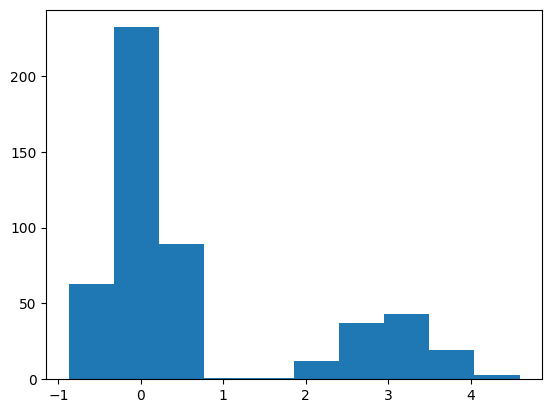

In [37]:
import matplotlib.pyplot as plt
plt.hist(dt)

In [25]:
import numpy as np
from src import utils

state = np.load("states.npy")

from src.functions import functions

In [73]:
Z_coe=tf.convert_to_tensor(utils.getZ(), dtype=tf.float64)
obs=tf.convert_to_tensor(utils.getglmmdata(), dtype=tf.float64)
def H_B(state):
    # returns the value of Hamiltonian B of equatioin (16) in Alenlov et al 2021.
    dim = len(state)//2
    theta, u, rho, p = state[0:13], state[13:dim], state[dim:dim+13], state[dim+13:]
    beta, mu, logla, logitw1 = theta[0:8], theta[8:10], theta[10:12], theta[12]
    part1 = tf.reduce_sum(beta**2/2/100) + tf.reduce_sum(mu**2/2/1) + tf.reduce_sum(logla**2/2/1) + tf.reduce_sum(logitw1**2/2/1) # prior density
    T, N, n, dim_p = 500, 128, 6, 8
    X = 3*tf.reshape(u, shape=(T,N))
    Z = tf.reshape(Z_coe, shape=(T,1,n,dim_p))
    y = tf.reshape(obs, shape=(T,1,n))
    f = 1/(1+tf.math.exp(-logitw1)) * tf.math.exp(-(X-mu[0])**2/2*tf.math.exp(logla[0])) + (1-1/(1+tf.math.exp(-logitw1))) * tf.math.exp(-(X-mu[1])**2/2*tf.math.exp(logla[1]))
    probs = 1/(1+tf.math.exp(-tf.expand_dims(X,-1) - tf.squeeze(tf.matmul(Z, tf.expand_dims(beta,axis=-1)),-1)))
    g = tf.reduce_prod(probs * y + (1-probs) * (1-y), axis=-1)
    prop = tf.math.exp(X**2/2/9)
    part2 = -tf.reduce_sum(tf.math.log(tf.reduce_mean(f*g*prop, axis=-1)))
    part3 = - tf.reduce_sum(logla)
    part4 = logitw1 + 2*tf.math.log(1+tf.math.exp(-logitw1))
    return tf.reduce_max(X)

state = tf.convert_to_tensor(state, dtype=tf.float64)
with tf.GradientTape() as tape:
    tape.watch(state)
    H = H_B(state)
grad = tape.gradient(H,state)

In [74]:
H

<tf.Tensor: shape=(), dtype=float64, numpy=113.16480654529508>

In [62]:
np.any(np.isinf(grad))

np.True_

In [49]:
import tensorflow as tf

In [29]:
H

<tf.Tensor: shape=(), dtype=float64, numpy=-inf>

In [47]:
import tensorflow as tf
import numpy as np
import pickle
import pdb
# 假设你的数据文件是以下路径列表
file_paths = [
    "/home/ycui/Documents/TSRLproject_JPMorgan/data/pmglmmB/test_0.obj",  # 每个文件可以是 TFRecord、CSV，甚至是 Numpy 文件
    "/home/ycui/Documents/TSRLproject_JPMorgan/data/pmglmmB/test_1.obj",
]

# 模拟一个简单的模型
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

def load_dict_file(file_path):
    with open(file_path.numpy().decode("utf-8"), 'rb') as f:
        data = pickle.load(f)
    states = np.array(data["states"], dtype=np.float32)
    timegrads = np.array(data["timegrads"], dtype=np.float32)
    return (states, timegrads)

# 2. 创建一个 tf.data.Dataset，按文件路径动态加载
file_dataset = tf.data.Dataset.from_tensor_slices(file_paths).repeat()

# 4. 逐文件训练
# 循环训练
epochs = 3  # 定义整个数据集的循环次数
for epoch in range(epochs):
    print(f"Epoch {epoch + 1}/{epochs}")
    for file_path in file_paths:

        print(f"Training on file: {file_path}")
        with open(file_path, 'rb') as f:
            data = pickle.load(f)
        # # 加载当前文件数据
        # file_dataset = load_dict_file(tf.convert_to_tensor(file_path))
        # # 用当前文件数据训练模型
        # pdb.set_trace()
        # model.fit(file_dataset, epochs=1)  # 每次训练 1 epoch

Epoch 1/3
Training on file: /home/ycui/Documents/TSRLproject_JPMorgan/data/pmglmmB/test_0.obj
Training on file: /home/ycui/Documents/TSRLproject_JPMorgan/data/pmglmmB/test_1.obj
Epoch 2/3
Training on file: /home/ycui/Documents/TSRLproject_JPMorgan/data/pmglmmB/test_0.obj
Training on file: /home/ycui/Documents/TSRLproject_JPMorgan/data/pmglmmB/test_1.obj
Epoch 3/3
Training on file: /home/ycui/Documents/TSRLproject_JPMorgan/data/pmglmmB/test_0.obj
Training on file: /home/ycui/Documents/TSRLproject_JPMorgan/data/pmglmmB/test_1.obj


In [30]:
it = iter(file_dataset)

In [45]:
next(it)

<tf.Tensor: shape=(), dtype=string, numpy=b'/home/ycui/Documents/TSRLproject_JPMorgan/data/pmglmmB/test_0.obj'>

In [5]:
import tensorflow as tf
path = "/home/ycui/Documents/TSRLproject_JPMorgan/data/pmglmmB"
def parse_tfrecord(proto):
    feature_description = {
        "states": tf.io.FixedLenFeature((13+500*128)*2, tf.float32),
        "timegrads": tf.io.FixedLenFeature((13+500*128)*2, tf.float32),
    }
    return tf.io.parse_single_example(proto, feature_description)

def load_tfrecord(filename, batch_size, repeat=True):
    dataset = tf.data.TFRecordDataset(filename)
    dataset = dataset.map(parse_tfrecord)
    if repeat:
        dataset = dataset.repeat()
    # dataset = dataset.shuffle(buffer_size=1000)       
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(buffer_size=tf.data.AUTOTUNE)
    return dataset

train_dataset = load_tfrecord(path+"_train.tfrecord", batch_size=3, repeat=True)
test_dataset = load_tfrecord(path+"_test.tfrecord", batch_size=3, repeat=False)




In [9]:
for batch in train_dataset.take(1):
    states, timegrads = batch["states"], batch["timegrads"]
    print(states.shape)
    print(timegrads.shape)

(3, 128026)
(3, 128026)


2025-01-27 12:47:44.573142: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [3]:
utils.write_pickle_to_tfrecord(train_file_paths[:2], path+"_train.tfrecord")

正在处理文件: /home/ycui/Documents/TSRLproject_JPMorgan/data/pmglmmB/train_0.obj
正在处理文件: /home/ycui/Documents/TSRLproject_JPMorgan/data/pmglmmB/train_1.obj
TFRecord 文件已保存到: /home/ycui/Documents/TSRLproject_JPMorgan/data/pmglmmB_train.tfrecord


In [14]:
import tensorflow as tf
def parse_tfrecord(example_proto):
    """
    解析 TFRecord 文件的每条记录
    """
    feature_description = {
        "states": tf.io.FixedLenFeature([(13+500*128)*2], tf.float32),  # 假设 key1 是 [128] 的向量
        "timegrads": tf.io.FixedLenFeature([(13+500*128)*2], tf.float32),   # 假设 key2 是 [64] 的向量
    }
    return tf.io.parse_single_example(example_proto, feature_description)

def load_tfrecord(filename):
    """
    从 TFRecord 文件中加载数据
    """
    dataset = tf.data.TFRecordDataset(filename)
    dataset = dataset.map(parse_tfrecord)
    return dataset

# 加载 TFRecord 文件
dataset = load_tfrecord("/home/ycui/Documents/TSRLproject_JPMorgan/data/pmglmmB_train.tfrecord")

# 遍历前 5 条记录
i = 0
for record in dataset.take(5):
    print("key1:", np.mean(abs(record["states"].numpy() - data["states"][i])))
    print("key2:", np.mean(abs(record["timegrads"].numpy()- data["timegrads"][i])))
    i+=1

key1: 1.7087865273399876e-08
key2: 9.555022271760462e-10
key1: 1.7053506619995017e-08
key2: 8.916188553875741e-10
key1: 1.702670330346447e-08
key2: 9.572850368317e-10
key1: 1.710598914058839e-08
key2: 9.078475563523864e-10
key1: 1.7068928274510536e-08
key2: 8.097247435734215e-10


2025-01-26 18:58:33.300620: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [6]:
with open("/home/ycui/Documents/TSRLproject_JPMorgan/data/pmglmmB/train_0.obj", "rb") as f:
    data = pickle.load(f)

In [13]:
import numpy as np